# 第二部分 2.1：机器学习概述

| 章节 | 内容 |
|------|------|
| **2.1 机器学习概述** | 问题类型、学习范式、基本流程 |
| **2.2 数据预处理** | 缺失值处理、特征缩放、编码 |

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, make_classification, make_regression, make_blobs, make_moons
from sklearn.model_selection import train_test_split

matplotlib.rcParams['font.family'] = ['PingFang SC', 'Heiti TC', 'Arial Unicode MS', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
print('环境就绪')

环境就绪


## 2.1 机器学习概述

### 什么是机器学习

机器学习是让计算机**从数据中自动找规律**，而不是手动编写规则。

传统编程：`数据 + 规则 → 答案`  
机器学习：`数据 + 答案 → 规则（模型）`

### 三种学习范式

| 类型 | 有无标签 | 目标 | 典型算法 |
|------|----------|------|----------|
| **监督学习** | 有 | 预测输出 y | 线性回归、逻辑回归、随机森林 |
| **无监督学习** | 无 | 发现数据结构 | K-Means、PCA、自编码器 |
| **强化学习** | 奖励信号 | 学习最优策略 | Q-Learning、PPO |

### 监督学习的两类问题

- **回归（Regression）**：预测连续值（房价、股价、温度）
- **分类（Classification）**：预测离散类别（垃圾邮件/正常、猫/狗/鸟）

### 无监督学习的主要任务

没有标签，目标是从数据本身发现结构、模式或异常。

| 任务 | 目标 | 典型算法 | 本章对应 |
|------|------|----------|----------|
| **聚类（Clustering）** | 将相似样本分组 | K-Means、DBSCAN | 2.4 |
| **降维（Dimensionality Reduction）** | 用更少维度表示数据，保留主要结构 | PCA、t-SNE、UMAP | 2.3 |
| **异常检测（Anomaly Detection）** | 找出与大多数样本显著不同的点 | Isolation Forest、DBSCAN | 2.4（DBSCAN 噪声点） |
| **生成建模（Generative Modeling）** | 学习数据分布，生成新样本 | VAE、GAN、扩散模型 | 第三章 |

**聚类 vs 分类**：看起来都是"给样本打标签"，但有三处本质不同：

| | 分类 | 聚类 |
|--|------|------|
| **训练数据** | 有标签 | 无标签 |
| **类别由谁定义** | 人事先定义（"垃圾邮件"/"正常邮件"） | 算法从数据结构中自行发现 |
| **输出标签的含义** | 预定义，语义明确 | 任意编号（0/1/2…），语义需人事后解读 |
| **能否用于新样本** | 是（天然泛化） | 取决于算法：K-Means 可以，DBSCAN 不行 |

### 标准 ML 工作流

```
原始数据 → 数据预处理 → 特征工程 → 模型选择 → 训练 → 评估 → 调参 → 部署
```

## 2.2 数据预处理

真实数据往往有缺失值、量纲不一致、类别型特征等问题，直接喂给模型会影响效果。预处理是 ML 流程中最耗时也最重要的环节。

### 缺失值处理

- **删除**：缺失比例高的列/行
- **填充**：均值/中位数（数值）、众数/固定值（类别）
- **预测填充**：用其他特征训练模型来预测缺失值

### 特征缩放

许多算法（KNN、SVM、神经网络、线性回归+正则化）对特征量纲敏感，需要缩放。树模型不需要缩放。

| 方法 | 公式 | 特点 |
|------|------|------|
| **StandardScaler** | (x - μ) / σ | 均值0方差1，适合大多数场景 |
| **MinMaxScaler** | (x - min) / (max - min) | 压缩到 [0,1]，对异常值敏感 |
| **RobustScaler** | (x - 中位数) / IQR | 对异常值不敏感 |

=== 原始数据 ===
 年龄（岁）  月收入（元）  工作年限（年）
    25    8000        2
    32   25000        8
    45   15000       20
    28   12000        5
    52   45000       28

各特征的数值范围和标准差：
  年龄（岁）        范围     25 ~     52，标准差 =     11.6
  月收入（元）       范围   8000 ~  45000，标准差 =  14815.5
  工作年限（年）      范围      2 ~     28，标准差 =     11.0

⚠️  问题：月收入的数值是年龄的约 1000 倍、是工作年限的约 3000 倍
   对于 KNN、SVM 等基于距离的算法，样本间距离几乎完全由月收入决定
   年龄和工作年限的差异被完全淹没，相当于这两个特征没有参与计算


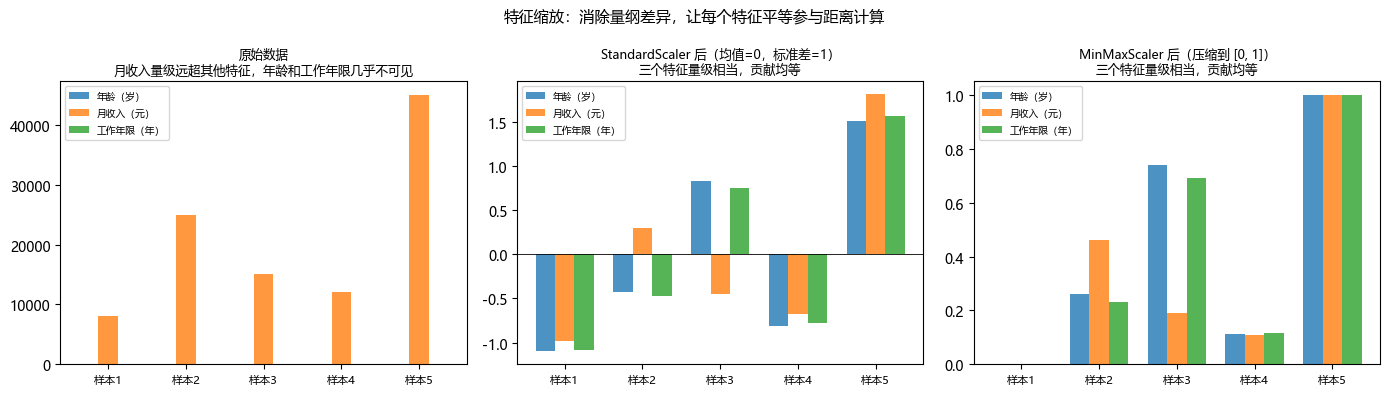


=== StandardScaler 后（均值=0，标准差=1）===
 年龄（岁）  月收入（元）  工作年限（年）
 -1.10   -0.98    -1.08
 -0.42    0.30    -0.47
  0.83   -0.45     0.75
 -0.81   -0.68    -0.77
  1.51    1.81     1.57

=== MinMaxScaler 后（范围 [0, 1]）===
 年龄（岁）  月收入（元）  工作年限（年）
  0.00    0.00     0.00
  0.26    0.46     0.23
  0.74    0.19     0.69
  0.11    0.11     0.12
  1.00    1.00     1.00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# ── 原始数据：三个特征量纲差异悬殊 ──────────────────────────
df = pd.DataFrame({
    '年龄（岁）':    [25, 32, 45, 28, 52],
    '月收入（元）':  [8000, 25000, 15000, 12000, 45000],
    '工作年限（年）': [2, 8, 20, 5, 28],
})

print("=== 原始数据 ===")
print(df.to_string(index=False))
print("\n各特征的数值范围和标准差：")
for col in df.columns:
    print(f"  {col:<12} 范围 {df[col].min():>6} ~ {df[col].max():>6}，标准差 = {df[col].std():>8.1f}")

print("\n⚠️  问题：月收入的数值是年龄的约 1000 倍、是工作年限的约 3000 倍")
print("   对于 KNN、SVM 等基于距离的算法，样本间距离几乎完全由月收入决定")
print("   年龄和工作年限的差异被完全淹没，相当于这两个特征没有参与计算")

# ── 缩放处理 ──────────────────────────────────────────────────
df_std    = pd.DataFrame(StandardScaler().fit_transform(df), columns=df.columns)
df_minmax = pd.DataFrame(MinMaxScaler().fit_transform(df),   columns=df.columns)

# ── 可视化：原始 vs 两种缩放结果 ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
x     = np.arange(len(df))
width = 0.25
colors = ['C0', 'C1', 'C2']

for ax, data, title in zip(axes,
    [df, df_std, df_minmax],
    ['原始数据\n月收入量级远超其他特征，年龄和工作年限几乎不可见',
     'StandardScaler 后（均值=0，标准差=1）\n三个特征量级相当，贡献均等',
     'MinMaxScaler 后（压缩到 [0, 1]）\n三个特征量级相当，贡献均等']):
    for i, (col, c) in enumerate(zip(data.columns, colors)):
        ax.bar(x + i * width, data[col], width, label=col, color=c, alpha=0.8)
    ax.set_xticks(x + width)
    ax.set_xticklabels([f'样本{i+1}' for i in range(len(df))], fontsize=8)
    ax.axhline(0, color='k', lw=0.6)
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle('特征缩放：消除量纲差异，让每个特征平等参与距离计算', fontsize=11)
plt.tight_layout()
plt.show()

print("\n=== StandardScaler 后（均值=0，标准差=1）===")
print(df_std.round(2).to_string(index=False))
print("\n=== MinMaxScaler 后（范围 [0, 1]）===")
print(df_minmax.round(2).to_string(index=False))

### 类别特征编码

类别特征（如城市、教育程度、商品类型）无法直接输入模型，需要转换为数值。

| 方法 | 适用场景 | 注意 |
|------|----------|------|
| **LabelEncoder** | 有序类别（低/中/高）、树模型的任意类别 | 不适合无序类别 + 线性模型：会误引入大小关系 |
| **OrdinalEncoder** | 多列有序类别，需手动指定顺序 | 与 LabelEncoder 类似，但支持多列且顺序可控 |
| **OneHotEncoder** | 无序类别 + 线性模型 / SVM / 神经网络 | 类别数量多时（几十上百个）会导致维度爆炸 |

**选择原则**：
- **树模型**（随机森林、XGBoost）：`LabelEncoder` 即可，树不受数值大小误导
- **线性模型 / SVM**：无序类别必须用 `OneHotEncoder`；有序类别用 `OrdinalEncoder` 并指定顺序
- **高基数类别**（如用户 ID、城市名，几百个取值）：`OneHotEncoder` 维度爆炸，需考虑 Target Encoding 或 Embedding